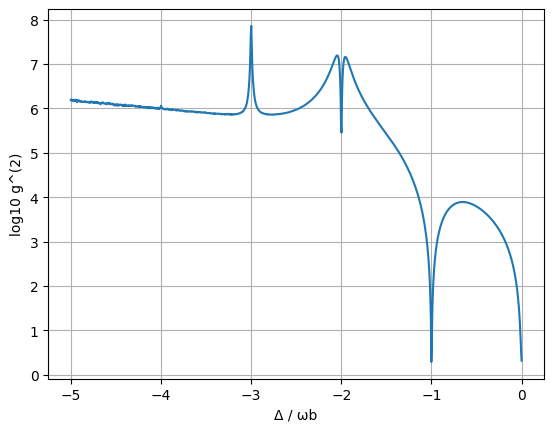

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# ---------- parameters ----------
wb = 1.0
lam = 0.03
Omega = 0.003

kappa = 0.002
gamma = 0.0002
gamma_phi = 0.0004

n_max = 15

# ---------- operators ----------
b = destroy(n_max+1)
bd = b.dag()
num = bd * b
I_ph = qeye(n_max+1)

sigma = basis(2,0) * basis(2,1).dag()   # |v><c|
sigmad = sigma.dag()
proj_c = sigmad * sigma
I_qd = qeye(2)

# tensor operators
b_full = tensor(I_qd, b)
bd_full = tensor(I_qd, bd)
num_full = tensor(I_qd, num)

sigma_full = tensor(sigma, I_ph)
sigmad_full = tensor(sigmad, I_ph)
proj_c_full = tensor(proj_c, I_ph)

# collapse operators
c_ops = [
    np.sqrt(kappa) * b_full,
    np.sqrt(gamma) * sigma_full,
    np.sqrt(gamma_phi) * proj_c_full
]

# ---------- sweep detuning ----------
x_axis = np.linspace(-5, 0, 1000)
g2_array = []

for Delta in x_axis:
    H = (
        wb * num_full
        + Delta * proj_c_full
        + lam * proj_c_full * (b_full + bd_full)
        + Omega * (sigma_full + sigmad_full)
    )

    rho_ss = steadystate(H, c_ops)

    n_expect = expect(num_full, rho_ss)
    g2 = expect(bd_full*bd_full*b_full*b_full, rho_ss) / (n_expect**2)

    g2_array.append(np.real(g2))

# ---------- plot ----------
plt.plot(x_axis, np.log10(g2_array))
plt.xlabel('Δ / ωb')
plt.ylabel('log10 g^(2)')
plt.grid()
plt.show()

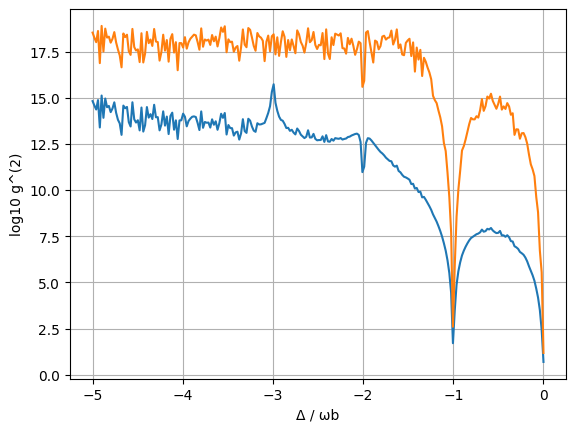

In [38]:
# ---------- sweep detuning ----------
x_axis = np.linspace(-5, 0, 250)
g3_array = []
g4_array = []

def make_physical(rho):
    # convert to numpy array
    rho_mat = rho.full()

    # enforce Hermiticity first
    rho_mat = (rho_mat + rho_mat.conj().T) / 2

    # diagonalize
    eigvals, eigvecs = np.linalg.eigh(rho_mat)

    # clip negative eigenvalues
    eigvals[eigvals < 0] = 0

    # reconstruct
    rho_mat = eigvecs @ np.diag(eigvals) @ eigvecs.conj().T

    # renormalize
    rho_mat = rho_mat / np.trace(rho_mat)

    # convert back to Qobj with same dims
    return Qobj(rho_mat, dims=rho.dims)

def g_n(rho, b_op, n):
    num_op = (b_op.dag()**n) * (b_op**n)
    n_expect = expect(b_op.dag()*b_op, rho)

    return expect(num_op, rho) / ((n_expect**n)+1e-30)

for Delta in x_axis:
    H = (
        wb * num_full
        + Delta * proj_c_full
        + lam * proj_c_full * (b_full + bd_full)
        + Omega * (sigma_full + sigmad_full)
    )

    rho_ss = steadystate(H, c_ops)
    rho_ss = make_physical(rho_ss)

    g3 = g_n(rho_ss, b_full, 3)
    g4 = g_n(rho_ss, b_full, 4)

    g3_array.append(g3)
    g4_array.append(g4)

# ---------- plot ----------
# plt.ylim(10, 16)
plt.plot(x_axis, np.log10(np.real(g3_array)))
plt.plot(x_axis, np.log10(np.real(g4_array)))
plt.xlabel('Δ / ωb')
plt.ylabel('log10 g^(2)')
plt.grid()
plt.show()